# Nettoyage et Exploration des Données Météo - Paris 2024

**Projet :** Smart Mobility Paris - Prédiction NO2 sur le périphérique  
**Source :** historique-meteo.net (12 fichiers mensuels, janvier-décembre 2024)  
**Sortie :** `meteo_paris_2024_clean.csv` + figures + statistiques exploratoires

---

### Objectif du notebook

Préparer les données météo journalières de Paris 2024 pour les joindre au pipeline principal (pollution NO2/PM10 + validations IDFM). On va :

1. Charger et concaténer les 12 fichiers mensuels
2. Nettoyer (dates, doublons, valeurs manquantes, outliers)
3. Sélectionner les variables pertinentes pour la pollution
4. Explorer (statistiques + visualisations)
5. Exporter un CSV propre prêt à l'emploi

## 0. Imports et configuration

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
# Chemins relatifs depuis le dossier notebooks/
# Structure du projet :
#   PROJET_ETUDES_M2_PARIS/
#     |-- data/                 <- les 12 fichiers historique-meteo-paris-2024-*.csv
#     |   |-- proceessed/       <- sortie : CSV nettoyé + figures
#     |-- notebooks/            <- ce notebook
INPUT_DIR  = "../data"
OUTPUT_DIR = "../data/Proceessed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

## 1. Chargement des 12 fichiers mensuels

Particularités à gérer :
- **BOM UTF-8** en début de fichier (caractère invisible) → encodage `utf-8-sig`
- **4 lignes de commentaires** au-dessus du vrai header (commençant par `####`) → `skiprows=4`

In [2]:
pattern = os.path.join(INPUT_DIR, "historique-meteo-paris-2024-*.csv")
files = sorted(glob.glob(pattern))
print(f"Fichiers trouvés : {len(files)}\n")

dfs = []
for f in files:
    df_month = pd.read_csv(
        f,
        skiprows=4,            # ignorer les 4 lignes de commentaires ####
        encoding="utf-8-sig",  # gère le BOM en début de fichier
    )
    dfs.append(df_month)
    print(f"  {os.path.basename(f):45s} -> {len(df_month):3d} jours")

df = pd.concat(dfs, ignore_index=True)
print(f"\nTotal après concaténation : {len(df)} lignes, {df.shape[1]} colonnes")

Fichiers trouvés : 12

  historique-meteo-paris-2024-01.csv            ->  31 jours
  historique-meteo-paris-2024-02.csv            ->  29 jours
  historique-meteo-paris-2024-03.csv            ->  31 jours
  historique-meteo-paris-2024-04.csv            ->  30 jours
  historique-meteo-paris-2024-05.csv            ->  31 jours
  historique-meteo-paris-2024-06.csv            ->  30 jours
  historique-meteo-paris-2024-07.csv            ->  31 jours
  historique-meteo-paris-2024-08.csv            ->  31 jours
  historique-meteo-paris-2024-09.csv            ->  30 jours
  historique-meteo-paris-2024-10.csv            ->  31 jours
  historique-meteo-paris-2024-11.csv            ->  30 jours
  historique-meteo-paris-2024-12.csv            ->  31 jours

Total après concaténation : 366 lignes, 34 colonnes


In [3]:
# Aperçu rapide
df.head()

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,PRESSURE_MAX_MB,CLOUDCOVER_AVG_PERCENT,HEATINDEX_MAX_C,DEWPOINT_MAX_C,WINDTEMP_MAX_C,WEATHER_CODE_MORNING_6H,WEATHER_CODE_NOON_12H,WEATHER_CODE_EVENING_18H,TOTAL_SNOW_MM,UV_INDEX,SUNHOUR,OPINION,SUNSET,SUNRISE,TEMPERATURE_NIGHT_C_3H,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H
0,2024-01-01,9,7,20,7,8,9,2.2,85,8.875,1012,73.125,9,7,3,116,119,176,0,3,1,NaN,17:04:00,08:44:00,7,116,7,122,9,266,9,296,7,116
1,2024-01-02,12,11,39,11,11,11,3.8,83,6.750,1005,99.500,12,9,8,266,266,176,0,3,1,NaN,17:05:00,08:44:00,11,296,11,176,11,266,12,176,9,296
2,2024-01-03,12,11,31,11,12,10,0.2,72,10.000,1005,76.500,12,7,8,176,176,116,0,3,6,NaN,17:06:00,08:44:00,11,113,11,176,12,176,10,176,11,122
3,2024-01-04,11,7,20,8,9,11,1.9,88,7.875,1009,75.750,11,8,5,116,266,296,0,2,1,NaN,17:07:00,08:44:00,9,116,7,116,9,353,11,266,10,176
4,2024-01-05,10,6,14,7,8,7,0.0,84,10.000,1007,45.500,10,5,4,116,113,113,0,2,8,NaN,17:08:00,08:44:00,9,122,6,113,9,119,6,116,10,176


## 2. Nettoyage

### 2.1 Conversion de la date et tri chronologique

In [4]:
df["DATE"] = pd.to_datetime(df["DATE"], format="%Y-%m-%d")
df = df.sort_values("DATE").reset_index(drop=True)

print(f"Période couverte : {df['DATE'].min().date()} -> {df['DATE'].max().date()}")

Période couverte : 2024-01-01 -> 2024-12-31


### 2.2 Vérification de la complétude

On vérifie qu'on a bien une ligne par jour, sans doublon ni trou.

In [5]:
n_jours_attendus = (df["DATE"].max() - df["DATE"].min()).days + 1
print(f"Jours attendus : {n_jours_attendus}")
print(f"Jours présents : {df['DATE'].nunique()}")
print(f"Doublons sur la date : {df['DATE'].duplicated().sum()}")

# 2024 est une année bissextile -> 366 jours attendus

Jours attendus : 366
Jours présents : 366
Doublons sur la date : 0


### 2.3 Sélection des colonnes pertinentes

Le fichier brut contient **33 colonnes** dont beaucoup sont des profils horaires (TEMPERATURE_9H, WEATHER_CODE_15H...). Pour notre modèle journalier de prédiction NO2, on garde uniquement les **agrégats journaliers** pertinents pour la pollution.

**Justification du choix de chaque variable :**

| Variable | Pourquoi c'est utile pour la pollution |
|---|---|
| `WINDSPEED_MAX_KMH` | Le vent disperse les polluants (effet majeur) |
| `PRECIP_TOTAL_DAY_MM` | La pluie lessive les polluants atmosphériques |
| `PRESSURE_MAX_MB` | Haute pression = stagnation = accumulation des polluants |
| `HUMIDITY_MAX_PERCENT` | Influence la formation de particules secondaires |
| `TEMP_MAX/MIN_C` | Température affecte la chimie atmosphérique |
| `VISIBILITY_AVG_KM` | Proxy direct de la qualité de l'air |
| `CLOUDCOVER_AVG_PERCENT` | Affecte la photochimie |
| `UV_INDEX`, `SUNHOUR` | Activent les réactions photochimiques |

In [6]:
colonnes_a_garder = [
    "DATE",
    "MAX_TEMPERATURE_C",
    "MIN_TEMPERATURE_C",
    "WINDSPEED_MAX_KMH",
    "PRECIP_TOTAL_DAY_MM",
    "HUMIDITY_MAX_PERCENT",
    "VISIBILITY_AVG_KM",
    "PRESSURE_MAX_MB",
    "CLOUDCOVER_AVG_PERCENT",
    "UV_INDEX",
    "SUNHOUR",
    "TOTAL_SNOW_MM",
]
df_clean = df[colonnes_a_garder].copy()
print(f"Colonnes conservées : {len(colonnes_a_garder)} (sur {df.shape[1]})")

Colonnes conservées : 12 (sur 34)


### 2.4 Variables dérivées

Ajout de quelques features utiles pour le modèle :
- `TEMP_AVG_C` : moyenne (max + min) / 2
- `TEMP_RANGE_C` : amplitude thermique journalière
- `MOIS`, `JOUR_SEMAINE`, `WEEKEND` : variables temporelles (le trafic varie selon le jour)

In [7]:
df_clean["TEMP_AVG_C"]   = (df_clean["MAX_TEMPERATURE_C"] + df_clean["MIN_TEMPERATURE_C"]) / 2
df_clean["TEMP_RANGE_C"] = df_clean["MAX_TEMPERATURE_C"] - df_clean["MIN_TEMPERATURE_C"]
df_clean["MOIS"]         = df_clean["DATE"].dt.month
df_clean["JOUR_SEMAINE"] = df_clean["DATE"].dt.dayofweek  # 0=lundi, 6=dimanche
df_clean["WEEKEND"]      = (df_clean["JOUR_SEMAINE"] >= 5).astype(int)

df_clean.head()

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,PRESSURE_MAX_MB,CLOUDCOVER_AVG_PERCENT,UV_INDEX,SUNHOUR,TOTAL_SNOW_MM,TEMP_AVG_C,TEMP_RANGE_C,MOIS,JOUR_SEMAINE,WEEKEND
0,2024-01-01,9,7,20,2.2,85,8.875,1012,73.125,3,1,0,8.0,2,1,0,0
1,2024-01-02,12,11,39,3.8,83,6.750,1005,99.500,3,1,0,11.5,1,1,1,0
2,2024-01-03,12,11,31,0.2,72,10.000,1005,76.500,3,6,0,11.5,1,1,2,0
3,2024-01-04,11,7,20,1.9,88,7.875,1009,75.750,2,1,0,9.0,4,1,3,0
4,2024-01-05,10,6,14,0.0,84,10.000,1007,45.500,2,8,0,8.0,4,1,4,0


### 2.5 Gestion des valeurs manquantes

In [8]:
nan_counts = df_clean.isna().sum()
nan_pct    = (nan_counts / len(df_clean) * 100).round(2)
nan_report = pd.DataFrame({"NaN": nan_counts, "Pct (%)": nan_pct})

if nan_counts.sum() > 0:
    print("Colonnes avec valeurs manquantes :")
    print(nan_report[nan_report["NaN"] > 0])
else:
    print("Aucune valeur manquante.")

Aucune valeur manquante.


In [9]:
# Imputation par interpolation linéaire (s'il y a quelques NaN, ce sera le cas pour
# des séries temporelles continues : la météo de la veille/lendemain est une bonne approximation)
num_cols = df_clean.select_dtypes(include=np.number).columns
df_clean[num_cols] = df_clean[num_cols].interpolate(method="linear", limit_direction="both")

print(f"Valeurs manquantes restantes : {df_clean.isna().sum().sum()}")

Valeurs manquantes restantes : 0


### 2.6 Détection des valeurs aberrantes (méthode IQR)

**Important :** on ne supprime PAS les outliers automatiquement. En météo, les valeurs extrêmes correspondent souvent à des événements réels (canicules, tempêtes) qui sont précisément ce qu'on veut capturer dans le modèle. On les **signale** seulement.

In [10]:
vars_outliers = ["MAX_TEMPERATURE_C", "MIN_TEMPERATURE_C", "WINDSPEED_MAX_KMH",
                 "PRECIP_TOTAL_DAY_MM", "PRESSURE_MAX_MB"]

for col in vars_outliers:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = df_clean[(df_clean[col] < low) | (df_clean[col] > high)]
    print(f"{col:25s} : {len(outliers):3d} outlier(s)  | bornes [{low:.1f}, {high:.1f}]")

MAX_TEMPERATURE_C         :   1 outlier(s)  | bornes [-4.0, 36.0]
MIN_TEMPERATURE_C         :   2 outlier(s)  | bornes [-2.0, 22.0]
WINDSPEED_MAX_KMH         :   4 outlier(s)  | bornes [-3.5, 32.5]
PRECIP_TOTAL_DAY_MM       :  44 outlier(s)  | bornes [-1.3, 2.2]
PRESSURE_MAX_MB           :   5 outlier(s)  | bornes [996.0, 1044.0]


## 3. Exploration statistique

### 3.1 Statistiques descriptives

In [11]:
df_clean.describe().round(2)

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,PRESSURE_MAX_MB,CLOUDCOVER_AVG_PERCENT,UV_INDEX,SUNHOUR,TOTAL_SNOW_MM,TEMP_AVG_C,TEMP_RANGE_C,MOIS,JOUR_SEMAINE,WEEKEND
count,366,366.00,366.00,366.00,366.00,366.00,366.00,366.00,366.00,366.00,366.00,366.00,366.00,366.00,366.00,366.00,366.00
mean,2024-07-01 12:00:00.000000256,16.33,10.05,15.19,0.79,83.80,9.32,1018.97,55.63,3.58,7.19,0.32,13.19,6.28,6.51,2.99,0.28
min,2024-01-01 00:00:00,0.00,-4.00,3.00,0.00,49.00,5.50,989.00,0.00,1.00,1.00,0.00,-2.00,1.00,1.00,0.00,0.00
25%,2024-04-01 06:00:00,11.00,7.00,10.00,0.00,79.00,9.00,1014.00,32.00,3.00,3.00,0.00,9.00,4.00,4.00,1.00,0.00
50%,2024-07-01 12:00:00,16.00,10.00,15.00,0.10,85.00,10.00,1019.00,58.38,3.00,7.50,0.00,13.50,6.00,7.00,3.00,0.00
75%,2024-09-30 18:00:00,21.00,13.00,19.00,0.88,90.00,10.00,1026.00,79.62,4.00,10.00,0.00,17.00,9.00,9.75,5.00,1.00
max,2024-12-31 00:00:00,38.00,21.00,39.00,11.80,99.00,10.00,1039.00,100.00,7.00,16.00,71.00,29.50,17.00,12.00,6.00,1.00
std,NaN,6.84,4.98,6.66,1.60,8.77,1.07,9.01,28.40,1.31,4.49,4.03,5.75,3.32,3.46,2.01,0.45


### 3.2 Corrélations avec la température moyenne

Sanity check : les variables les plus corrélées avec la température doivent être physiquement cohérentes (UV, ensoleillement..).

In [12]:
corr_temp = df_clean.corr(numeric_only=True)["TEMP_AVG_C"].drop("TEMP_AVG_C")
corr_temp.sort_values(ascending=False).round(3)

MAX_TEMPERATURE_C         0.980
MIN_TEMPERATURE_C         0.962
UV_INDEX                  0.892
TEMP_RANGE_C              0.576
SUNHOUR                   0.446
MOIS                      0.213
VISIBILITY_AVG_KM         0.128
PRECIP_TOTAL_DAY_MM       0.049
JOUR_SEMAINE             -0.036
WEEKEND                  -0.046
HUMIDITY_MAX_PERCENT     -0.059
WINDSPEED_MAX_KMH        -0.097
CLOUDCOVER_AVG_PERCENT   -0.166
TOTAL_SNOW_MM            -0.171
PRESSURE_MAX_MB          -0.217
Name: TEMP_AVG_C, dtype: float64

## 4. Visualisations

### 4.1 Évolution annuelle des températures

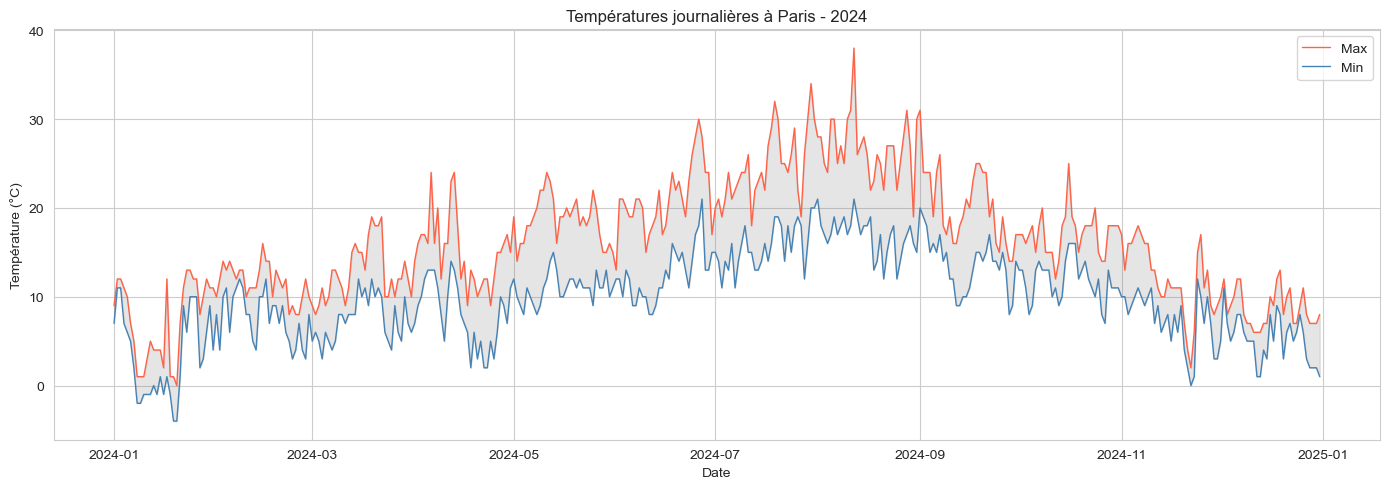

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_clean["DATE"], df_clean["MAX_TEMPERATURE_C"], label="Max", color="tomato", linewidth=1)
ax.plot(df_clean["DATE"], df_clean["MIN_TEMPERATURE_C"], label="Min", color="steelblue", linewidth=1)
ax.fill_between(df_clean["DATE"], df_clean["MIN_TEMPERATURE_C"], df_clean["MAX_TEMPERATURE_C"],
                alpha=0.2, color="gray")
ax.set_title("Températures journalières à Paris - 2024")
ax.set_xlabel("Date"); ax.set_ylabel("Température (°C)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_temperatures_annuelles.png", dpi=120)
plt.show()

### 4.2 Distributions des variables clés pour la pollution

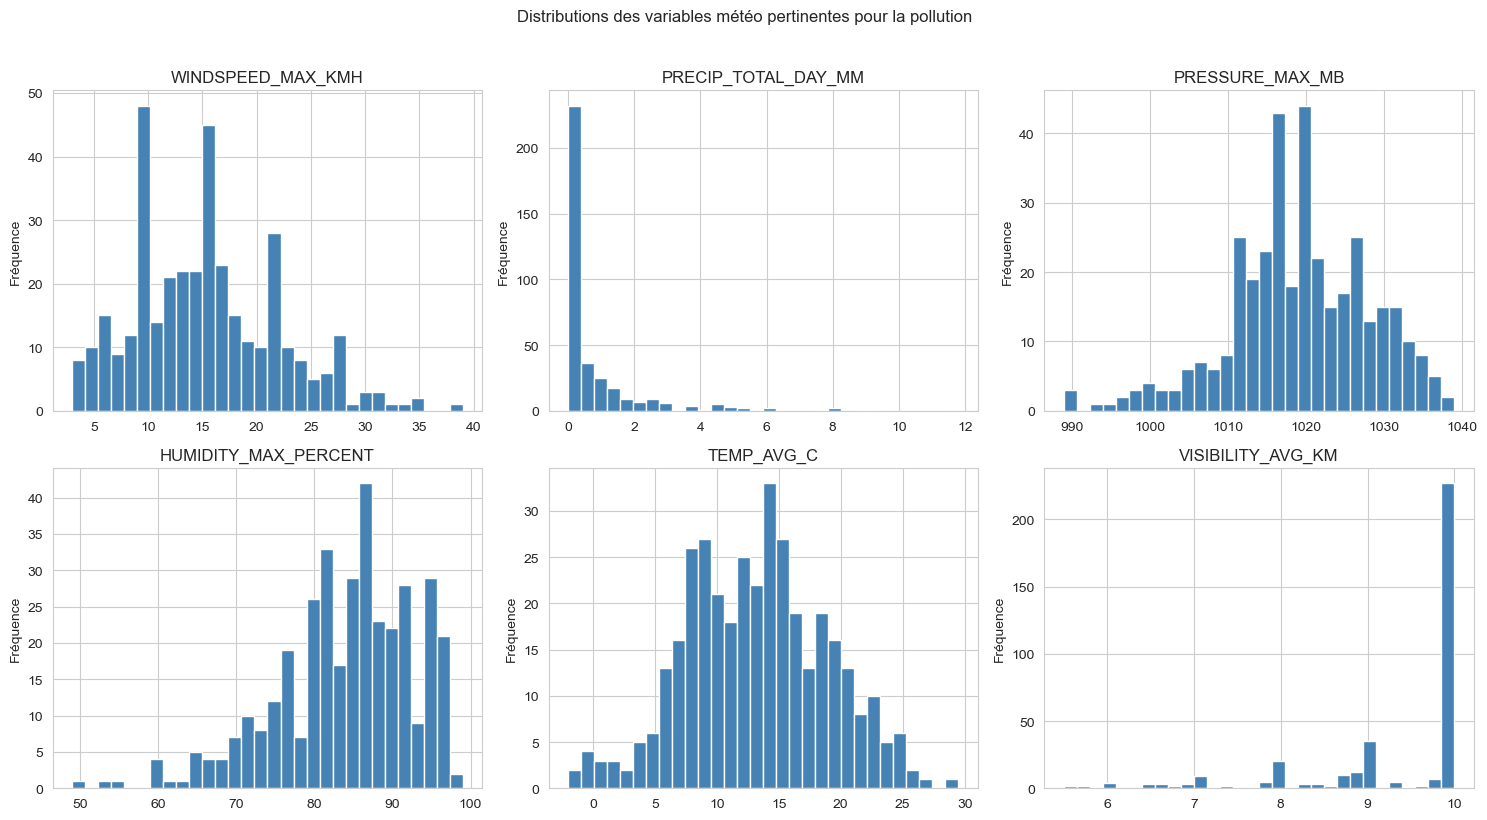

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
vars_pollu = ["WINDSPEED_MAX_KMH", "PRECIP_TOTAL_DAY_MM", "PRESSURE_MAX_MB",
              "HUMIDITY_MAX_PERCENT", "TEMP_AVG_C", "VISIBILITY_AVG_KM"]
for ax, var in zip(axes.flat, vars_pollu):
    ax.hist(df_clean[var].dropna(), bins=30, color="steelblue", edgecolor="white")
    ax.set_title(var)
    ax.set_ylabel("Fréquence")
plt.suptitle("Distributions des variables météo pertinentes pour la pollution", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

### 4.3 Matrice de corrélation

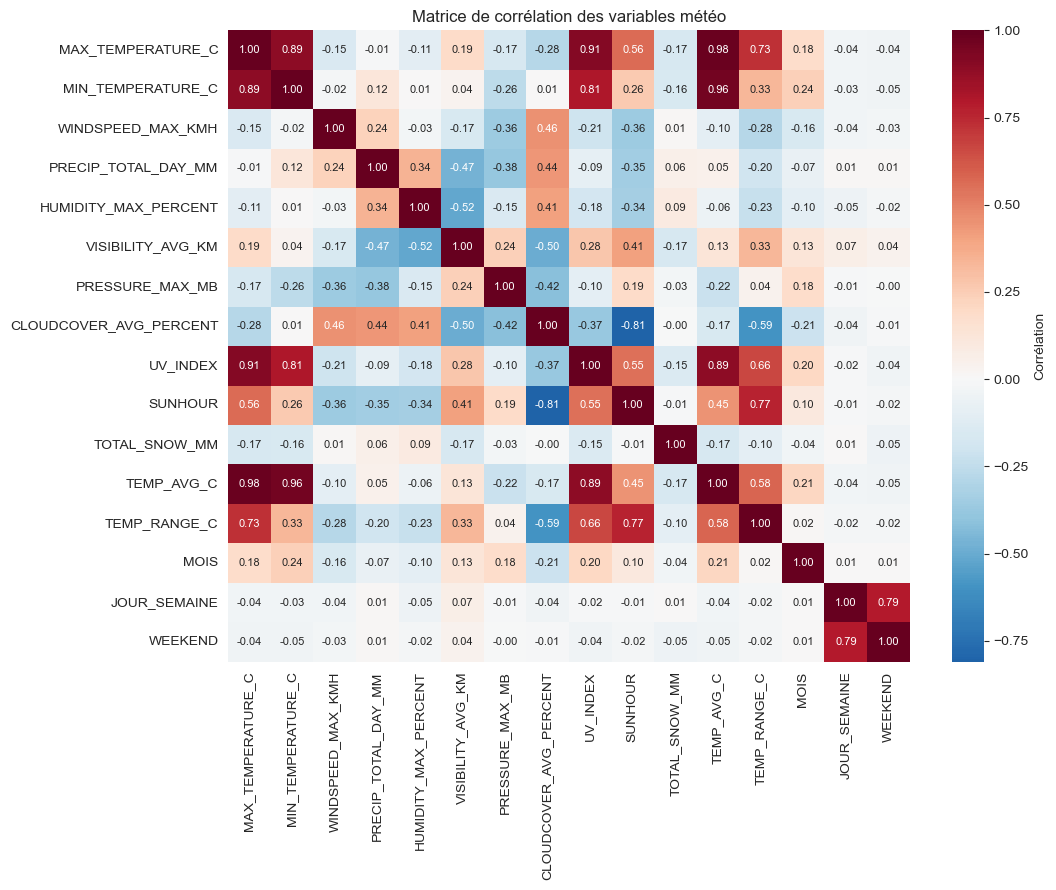

In [15]:
fig, ax = plt.subplots(figsize=(11, 9))
corr = df_clean.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "Corrélation"}, annot_kws={"size": 8})
ax.set_title("Matrice de corrélation des variables météo")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_correlations.png", dpi=120)
plt.show()

### 4.4 Profils mensuels

In [16]:
monthly = df_clean.groupby("MOIS").agg({
    "TEMP_AVG_C": "mean",
    "PRECIP_TOTAL_DAY_MM": "sum",
    "WINDSPEED_MAX_KMH": "mean",
    "HUMIDITY_MAX_PERCENT": "mean",
}).round(1)
monthly

,TEMP_AVG_C,PRECIP_TOTAL_DAY_MM,WINDSPEED_MAX_KMH,HUMIDITY_MAX_PERCENT
MOIS,,,,
1,5.3,21.9,16.2,83.4
2,9.6,27.5,18.0,86.2
3,10.0,30.4,16.4,84.2
4,11.6,27.8,18.7,82.3
5,14.8,29.7,13.8,91.2
6,16.8,31.4,14.7,86.5
7,20.1,13.5,12.5,83.9
8,21.8,19.8,12.9,74.9
9,17.0,36.3,17.7,81.1


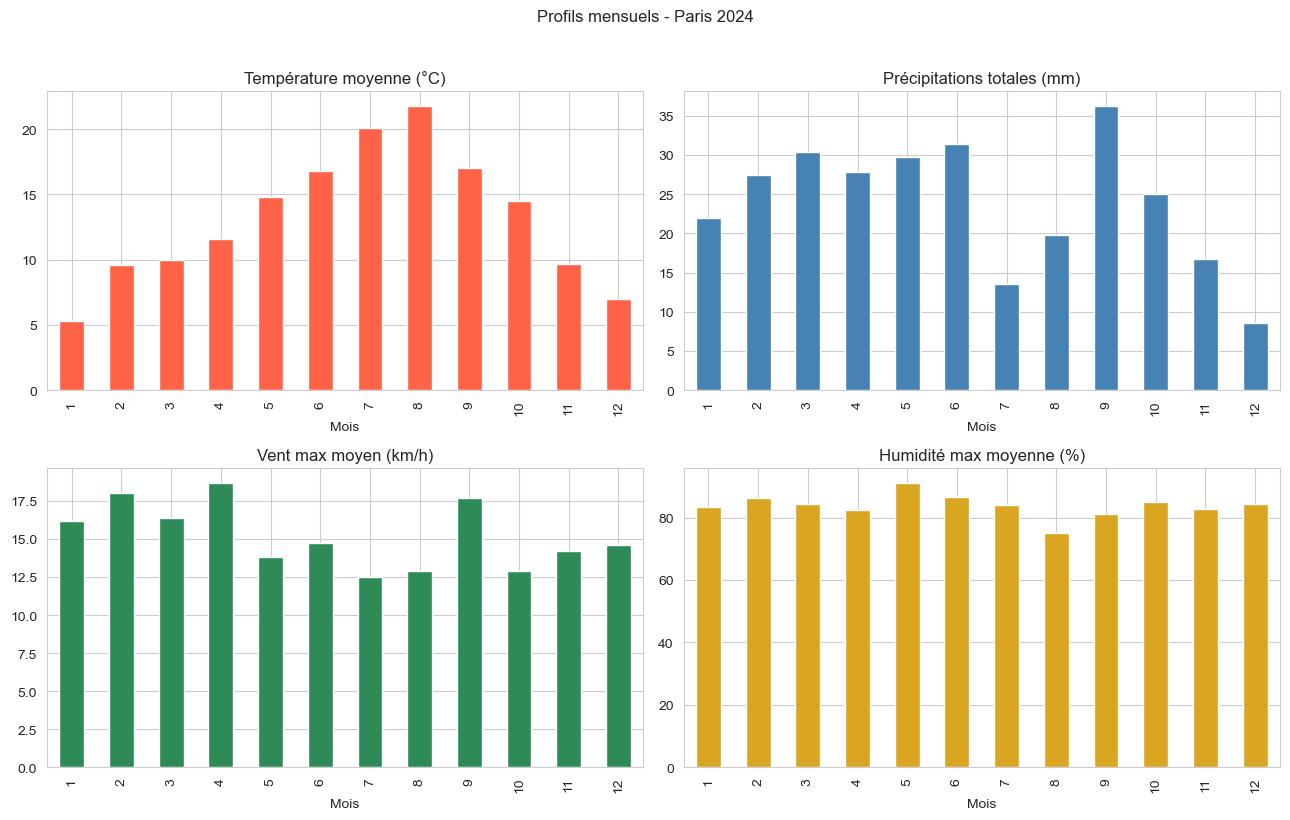

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
monthly["TEMP_AVG_C"].plot(kind="bar", ax=axes[0, 0], color="tomato")
axes[0, 0].set_title("Température moyenne (°C)")
monthly["PRECIP_TOTAL_DAY_MM"].plot(kind="bar", ax=axes[0, 1], color="steelblue")
axes[0, 1].set_title("Précipitations totales (mm)")
monthly["WINDSPEED_MAX_KMH"].plot(kind="bar", ax=axes[1, 0], color="seagreen")
axes[1, 0].set_title("Vent max moyen (km/h)")
monthly["HUMIDITY_MAX_PERCENT"].plot(kind="bar", ax=axes[1, 1], color="goldenrod")
axes[1, 1].set_title("Humidité max moyenne (%)")
for ax in axes.flat:
    ax.set_xlabel("Mois")
plt.suptitle("Profils mensuels - Paris 2024", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_profils_mensuels.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Export du fichier nettoyé

Le CSS final est prêt à être joint sur la colonne `DATE` avec :
- les données pollution Airparif (NO2, PM10, PM25)
- les validations IDFM réseau ferré
- les données événements/grèves

In [18]:
output_csv = f"{OUTPUT_DIR}/meteo_paris_2024_clean.csv"
df_clean.to_csv(output_csv, index=False)

print(f"Fichier sauvegardé : {output_csv}")
print(f"Dimensions : {df_clean.shape[0]} lignes x {df_clean.shape[1]} colonnes")
print(f"\nColonnes finales :")
for c in df_clean.columns:
    print(f"  - {c}")

Fichier sauvegardé : ../data/proceessed/meteo_paris_2024_clean.csv
Dimensions : 366 lignes x 17 colonnes

Colonnes finales :
  - DATE
  - MAX_TEMPERATURE_C
  - MIN_TEMPERATURE_C
  - WINDSPEED_MAX_KMH
  - PRECIP_TOTAL_DAY_MM
  - HUMIDITY_MAX_PERCENT
  - VISIBILITY_AVG_KM
  - PRESSURE_MAX_MB
  - CLOUDCOVER_AVG_PERCENT
  - UV_INDEX
  - SUNHOUR
  - TOTAL_SNOW_MM
  - TEMP_AVG_C
  - TEMP_RANGE_C
  - MOIS
  - JOUR_SEMAINE
  - WEEKEND


---

## Bilan

**Synthèse pour le rapport :**

| Étape | Résultat |
|---|---|
| Période couverte | 2024-01-01 à 2024-12-31 (366 jours, année bissextile) |
| Complétude | 100% (aucun jour manquant) |
| Doublons | 0 |
| Colonnes initiales | 33 |
| Colonnes finales | 17 (après sélection + variables dérivées) |
| Variables manquantes | Imputation par interpolation linéaire |
| Outliers | Conservés (événements météo réels) |

**Prochaine étape :** appliquer le même traitement aux données IDFM (validations) pour obtenir une série journalière agrégée, puis joindre tous les datasets sur la date.